# Predict F1 Pit Stops

## Import libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score
from imblearn.under_sampling import NearMiss

np.set_printoptions(threshold=np.inf)

## Load data + clean data

In [3]:
def load_clean(test=False):
    load_path = '/home/nguyen/AI_KO/data/f1_pit_stop/train.csv' if not test \
    else '/home/nguyen/AI_KO/data/f1_pit_stop/test.csv'
    df = pd.read_csv(load_path)

    # Remove id
    df.drop(['id'], axis=1, errors='ignore', inplace=True)

    # Rename columns
    df.rename({
        'Driver': 'driver',
        'Compound': 'compound',
        'Race': 'race',
        'Year': 'year',
        'PitStop': 'pit_stop',
        'LapNumber': 'lap_number',
        'Stint': 'stint',
        'TyreLife': 'tyre_life',
        'Position': 'position',
        'LapTime (s)': 'lap_time_s',
        'LapTime_Delta': 'lap_time_delta',
        'Cumulative_Degradation': 'cumulative_degradation',
        'RaceProgress': 'race_progress',
        'Position_Change': 'position_change',
        'PitNextLap': 'pit_next_lap'
    }, axis=1, inplace=True)

    # Correct dtypes, object => category
    dtype_mapping = {col: 'category' for col in df.select_dtypes(exclude=np.number)}
    df = df.astype(dtype_mapping)
    
    return df


df = load_clean()

In [4]:
def summary(df, heads=5):
    summary = pd.DataFrame({
        'dtypes': df.dtypes,
        'unique': df.nunique()
    })
    
    display(pd.concat([summary.T, df.head(heads)]))
summary(df)

,driver,compound,race,year,pit_stop,lap_number,stint,tyre_life,position,lap_time_s,lap_time_delta,cumulative_degradation,race_progress,position_change,pit_next_lap
dtypes,category,category,category,int64,int64,int64,int64,float64,int64,float64,float64,float64,float64,float64,float64
unique,887,5,26,4,2,78,8,78,20,37719,57532,142701,1898,37,2
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.54,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


### Target Analysis

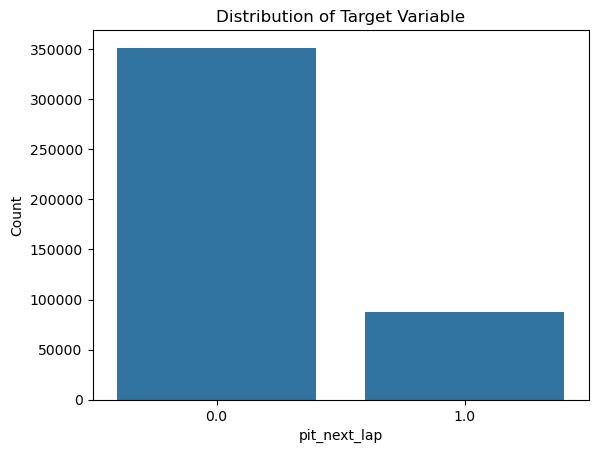

In [5]:
TARGET = 'pit_next_lap'

# Countplot TARGET
sns.countplot(x=TARGET, data=df)
plt.title('Distribution of Target Variable')
plt.xlabel(TARGET)
plt.ylabel('Count')
plt.show()

## GB model check
* LightGBM - Raw: 0.9386
  + Remove 'driver': 0.9435
* Stacking LightGBM + XGBoost: 0.9465

### Lightgbm

Cross-validated AUC scores: [0.9438407  0.94420819 0.94434419 0.94256608 0.94278043]
Mean AUC: 0.9435, Std AUC: 0.0007


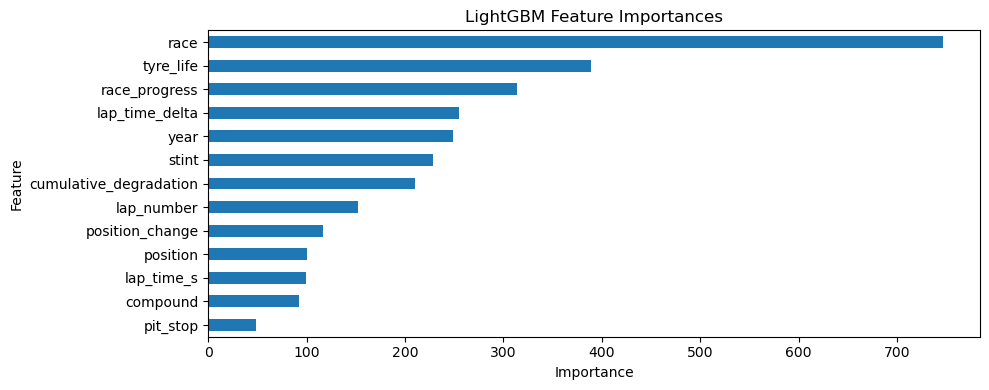

In [6]:
# Import cross_val_score for cross-validation
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

def lightgbm_cv_fi(X, y, cv=5):
    model = LGBMClassifier(random_state=42, verbose=-1, reg_alpha=0.1, reg_lambda=0.1)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f'Cross-validated AUC scores: {scores}')
    print(f'Mean AUC: {scores.mean():.4f}, Std AUC: {scores.std():.4f}')

    # Train on full data to get feature importances
    model.fit(X, y)
    # Display feature importances in barh, small figsize
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(10, 4))
    importances.plot(kind='barh')
    plt.title('LightGBM Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    

lightgbm_cv_fi(df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5)

## Stacking lightgbm + XGBoost

In [7]:
# # Import XGBoost and CatBoost
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

def stacking_cv_fi(X, y, cv=5):
    """
    Cross validate using stacking of LightGBM, XGBoost, CatBoost with meta learning LogisticRegression
    Display distributions of base model predictions
    """
    estimators = [
        ('lgbm', LGBMClassifier(random_state=42, verbose=-1, reg_alpha=0.1, reg_lambda=0.1)),
        ('xgb', XGBClassifier(random_state=42, enable_categorical=True,
                              eval_metric='logloss', reg_alpha=0.1, reg_lambda=0.1))
    ]
    model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=cv)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f'Stacking Cross-validated AUC scores: {scores}')
    print(f'Mean AUC: {scores.mean():.4f}, Std AUC: {scores.std():.4f}')

    # Display coefficients of meta model
    model.fit(X, y)
    meta_coefs = pd.Series(model.final_estimator_.coef_[0], index=[name for name, _ in estimators])
    print("Meta model coefficients:")
    print(meta_coefs)

stacking_cv_fi(df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5)

Stacking Cross-validated AUC scores: [0.9469041  0.94701709 0.94731112 0.94547712 0.94588177]
Mean AUC: 0.9465, Std AUC: 0.0007
Meta model coefficients:
lgbm    2.193812
xgb     4.660861
dtype: float64


## Feature engineering
* 'driver' always draw down the ROC AUC
* 'race' always needed for improving ROC AUC

In [8]:
summary(df)

,driver,compound,race,year,pit_stop,lap_number,stint,tyre_life,position,lap_time_s,lap_time_delta,cumulative_degradation,race_progress,position_change,pit_next_lap
dtypes,category,category,category,int64,int64,int64,int64,float64,int64,float64,float64,float64,float64,float64,float64
unique,887,5,26,4,2,78,8,78,20,37719,57532,142701,1898,37,2
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.54,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


/tmp/ipykernel_46928/1748099723.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['tyre_life_relative'] = df['tyre_life'] - df.groupby('compound')['tyre_life'].transform('mean')
/tmp/ipykernel_46928/1748099723.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['compound', 'tyre_life'])['pit_next_lap']
/tmp/ipykernel_46928/1748099723.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['race'

Cross-validated AUC scores: [0.94346559 0.9439054  0.94449077 0.94280933 0.9428408 ]
Mean AUC: 0.9435, Std AUC: 0.0006


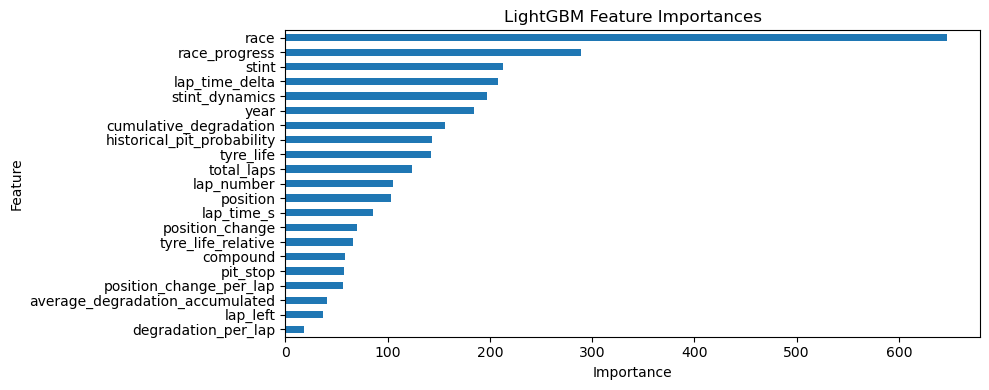

,driver,compound,race,year,pit_stop,lap_number,stint,tyre_life,position,lap_time_s,...,position_change,pit_next_lap,degradation_per_lap,average_degradation_accumulated,position_change_per_lap,stint_dynamics,tyre_life_relative,historical_pit_probability,total_laps,lap_left
dtypes,category,category,category,int64,int64,int64,int64,float64,int64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64
unique,887,5,26,4,2,78,8,78,20,37719,...,37,2,248585,353836,1373,194,293,229,30,78
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,...,5.0,1.0,-0.193949,0.538949,0.1,78.0,21.151559,0.378335,71,21
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,...,-3.0,0.0,-4.659571,-31.886714,-0.111111,14.0,-10.848441,0.205936,74,47
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,...,3.0,1.0,-0.342727,-4.5695,0.050847,66.0,4.151559,0.416919,70,11
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,...,0.0,0.0,-3.662,-3.662,0.0,2.0,-9.830294,0.022415,66,64
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,...,3.0,0.0,1.494167,-2.3565,0.115385,18.0,-11.848441,0.173297,58,32


In [19]:
df = load_clean()

# 0.9436
df['degradation_per_lap'] = df['lap_time_delta'] / df['tyre_life']

# 0.9435
df['average_degradation_accumulated'] = df['cumulative_degradation'] / df['tyre_life'] 

# 0.9374 (Dominant)
# df['driver_compound_interaction'] = df['driver'].astype(str) + '_' + df['compound'].astype(str) 
# df['driver_compound_interaction'] = df['driver_compound_interaction'].astype('category')

# 0.9435
df['position_change_per_lap'] = df['position_change'] / df['lap_number']

# stint dynamics 0.9432
df['stint_dynamics'] = df['stint'] * df['tyre_life']


# tyre_life_relative = tyre_life - avg_tyre_life_same_compound
df['tyre_life_relative'] = df['tyre_life'] - df.groupby('compound')['tyre_life'].transform('mean')

# historical_pit_probability
hist_pit_prob = (
    df
    .groupby(['compound', 'tyre_life'])['pit_next_lap']
    .mean()
    .reset_index()
    .rename(columns={
        'pit_next_lap': 'historical_pit_probability'
    })
)

df = df.merge(
    hist_pit_prob,
    on=['compound', 'tyre_life'],
    how='left'
)

race_laps = (
    df.groupby(['race', 'year'])['lap_number']
      .max()
      .reset_index()
      .rename(columns={'lap_number': 'total_laps'})
)

df = df.merge(
    race_laps,
    on=['race', 'year'],
    how='left'
)

# lap_left = total_laps - lap_number
df['lap_left'] = df['total_laps'] - df['lap_number']

lightgbm_cv_fi(df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5)

summary(df)

In [10]:
stacking_cv_fi(df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5)

Stacking Cross-validated AUC scores: [0.94622421 0.94667435 0.94720315 0.94521445 0.94536837]
Mean AUC: 0.9461, Std AUC: 0.0008
Meta model coefficients:
lgbm    2.440480
xgb     4.401783
dtype: float64


## Hyperparameter Tuning

In [11]:
lightgbm_params = {'n_estimators': 996, 
                   'learning_rate': 0.11534489032627117, 
                   'num_leaves': 20, 
                   'max_depth': 7, 
                   'reg_alpha': 0.47632296508229843, 
                   'reg_lambda': 0.3908266586261553}

xgb_params = {'n_estimators': 761, 
              'learning_rate': 0.058299165660521915, 
              'max_depth': 7, 
              'reg_alpha': 0.4488847422081284, 
              'reg_lambda': 0.10173115925973039}

In [78]:
# Hyperparameter tuning with Optuna for LightGBM
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 75, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 0.5)
    }
    
    model = LGBMClassifier(random_state=42, verbose=-1, **params)
    scores = cross_val_score(model, df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=None, show_progress_bar=True, timeout=6000) 
print("Best hyperparameters:", study.best_params)

[I 2026-05-17 16:21:13,298] A new study created in memory with name: no-name-74c062da-0e67-4c83-a6b8-ae51c5b4e350
   0%|          | 00:00/1:40:00/tmp/ipykernel_26362/1604059570.py:8: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'num_leaves': trial.suggest_int('num_leaves', 20, 75, 150),
/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [20, 75] and step=150, but the range is not divisible by `step`. It will be replaced with [20, 20].
  optuna_warn(
Best trial: 0. Best value: 0.944651:    0%|          | 00:11/1:40:00

[I 2026-05-17 16:21:24,339] Trial 0 finished with value: 0.9446511673583959 and parameters: {'n_estimators': 443, 'learning_rate': 0.05457758153197391, 'num_leaves': 20, 'max_depth': 7, 'reg_alpha': 0.36958992749268366, 'reg_lambda': 0.14859582104680819}. Best is trial 0 with value: 0.9446511673583959.


Best trial: 1. Best value: 0.946146:    0%|          | 00:21/1:40:00/tmp/ipykernel_26362/1604059570.py:8: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'num_leaves': trial.suggest_int('num_leaves', 20, 75, 150),
/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [20, 75] and step=150, but the range is not divisible by `step`. It will be replaced with [20, 20].
  optuna_warn(


[I 2026-05-17 16:21:35,087] Trial 1 finished with value: 0.9461464320742914 and parameters: {'n_estimators': 500, 'learning_rate': 0.17748134385370049, 'num_leaves': 20, 'max_depth': 4, 'reg_alpha': 0.1650877316478821, 'reg_lambda': 0.07098592219130084}. Best is trial 1 with value: 0.9461464320742914.


Best trial: 2. Best value: 0.946304:    1%|          | 00:32/1:40:00/tmp/ipykernel_26362/1604059570.py:8: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'num_leaves': trial.suggest_int('num_leaves', 20, 75, 150),
/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [20, 75] and step=150, but the range is not divisible by `step`. It will be replaced with [20, 20].
  optuna_warn(


...

Best trial: 160. Best value: 0.947664:   47%|████▋     | 46:43/1:40:00/tmp/ipykernel_26362/1604059570.py:8: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'num_leaves': trial.suggest_int('num_leaves', 20, 75, 150),
/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [20, 75] and step=150, but the range is not divisible by `step`. It will be replaced with [20, 20].
  optuna_warn(


[I 2026-05-17 17:07:57,138] Trial 170 finished with value: 0.947304740939739 and parameters: {'n_estimators': 984, 'learning_rate': 0.149325746270644, 'num_leaves': 20, 'max_depth': 9, 'reg_alpha': 0.4960602214564486, 'reg_lambda': 0.35750219813669076}. Best is trial 160 with value: 0.9476639367683637.


Best trial: 160. Best value: 0.947664:   47%|████▋     | 46:47/1:40:00


[W 2026-05-17 17:08:01,183] Trial 171 failed with parameters: {'n_estimators': 982, 'learning_rate': 0.12367139241008933, 'num_leaves': 20, 'max_depth': 9, 'reg_alpha': 0.48059315543687287, 'reg_lambda': 0.37723056943403666} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_26362/1604059570.py", line 15, in objective
    scores = cross_val_score(model, df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5, scoring='roc_auc')
  File "/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 677, in cross_val_score
    cv_results = cross_validate(
  File "/home/nguyen/mi

KeyboardInterrupt: 

In [97]:
# Hyperparameter tuning with Optuna for XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 0.5)
    }
    
    model = XGBClassifier(random_state=42, enable_categorical=True, eval_metric='logloss', **params)
    scores = cross_val_score(model, df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5, scoring='roc_auc')
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=None, show_progress_bar=True, timeout=6000) 
print("Best XGBoost hyperparameters:", study_xgb.best_params)

[I 2026-05-17 18:01:04,300] A new study created in memory with name: no-name-93561826-67de-46c3-963b-8c109d6a10b9
Best trial: 0. Best value: 0.942678:    1%|          | 00:34/1:40:00

[I 2026-05-17 18:01:38,981] Trial 0 finished with value: 0.9426776461839594 and parameters: {'n_estimators': 416, 'learning_rate': 0.21697325961026104, 'max_depth': 10, 'reg_alpha': 0.4002812001382471, 'reg_lambda': 0.4030914300390527}. Best is trial 0 with value: 0.9426776461839594.


Best trial: 1. Best value: 0.945508:    1%|          | 00:48/1:40:00

[I 2026-05-17 18:01:52,816] Trial 1 finished with value: 0.9455076855478431 and parameters: {'n_estimators': 335, 'learning_rate': 0.055254620309890236, 'max_depth': 6, 'reg_alpha': 0.12378905834157378, 'reg_lambda': 0.027745385140839796}. Best is trial 1 with value: 0.9455076855478431.


Best trial: 2. Best value: 0.946754:    1%|          | 00:56/1:40:00

...

Best trial: 155. Best value: 0.948154:   87%|████████▋ | 1:27:07/1:40:00

[I 2026-05-17 19:28:11,939] Trial 164 finished with value: 0.947966473917262 and parameters: {'n_estimators': 828, 'learning_rate': 0.06095210386236388, 'max_depth': 7, 'reg_alpha': 0.45634860792759824, 'reg_lambda': 0.10412069663422581}. Best is trial 155 with value: 0.9481535844797996.


Best trial: 155. Best value: 0.948154:   87%|████████▋ | 1:27:21/1:40:00


[W 2026-05-17 19:28:25,915] Trial 165 failed with parameters: {'n_estimators': 842, 'learning_rate': 0.06693097499548675, 'max_depth': 7, 'reg_alpha': 0.450199746075228, 'reg_lambda': 0.12764888899035529} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_26362/3415205371.py", line 12, in objective_xgb
    scores = cross_val_score(model, df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5, scoring='roc_auc')
  File "/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 677, in cross_val_score
    cv_results = cross_validate(
  File "/home/nguyen/micromamba/envs/ai

KeyboardInterrupt: 

## Final solution

In [12]:
# Stacking with LightGBM + XGBoost with tuned hyperparameters
estimators = [
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1, **lightgbm_params)),
    ('xgb', XGBClassifier(random_state=42, enable_categorical=True, eval_metric='logloss', **xgb_params))
]
model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
scores = cross_val_score(model, df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5, scoring='roc_auc')
print(f'Stacking with tuned hyperparameters Cross-validated AUC scores: {scores}')
print(f'Mean AUC: {scores.mean():.4f}, Std AUC: {scores.std():.4f}')

Stacking with tuned hyperparameters Cross-validated AUC scores: [0.94889842 0.94951065 0.94924117 0.94758117 0.94808694]
Mean AUC: 0.9487, Std AUC: 0.0007


## Build LogisticRegression model
* Raw: 0.8657

### Initial model

In [13]:
# Function to cross validate Logistic Regression with preprocessing steps, put into a pipeline
def lg_cv_fi(X, y, cv=5):
    numeric_features = X.select_dtypes(include=np.number).columns
    categorical_features = X.select_dtypes(exclude=np.number).columns

    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ])

    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f'Logistic Regression Cross-validated AUC scores: {scores}')
    print(f'Mean AUC: {scores.mean():.4f}, Std AUC: {scores.std():.4f}')

lg_cv_fi(df.drop([TARGET], axis=1), df[TARGET], cv=5)

Logistic Regression Cross-validated AUC scores: [0.8640778  0.86690256 0.86601802 0.86526272 0.86619776]
Mean AUC: 0.8657, Std AUC: 0.0010


### Normalize feature distributions

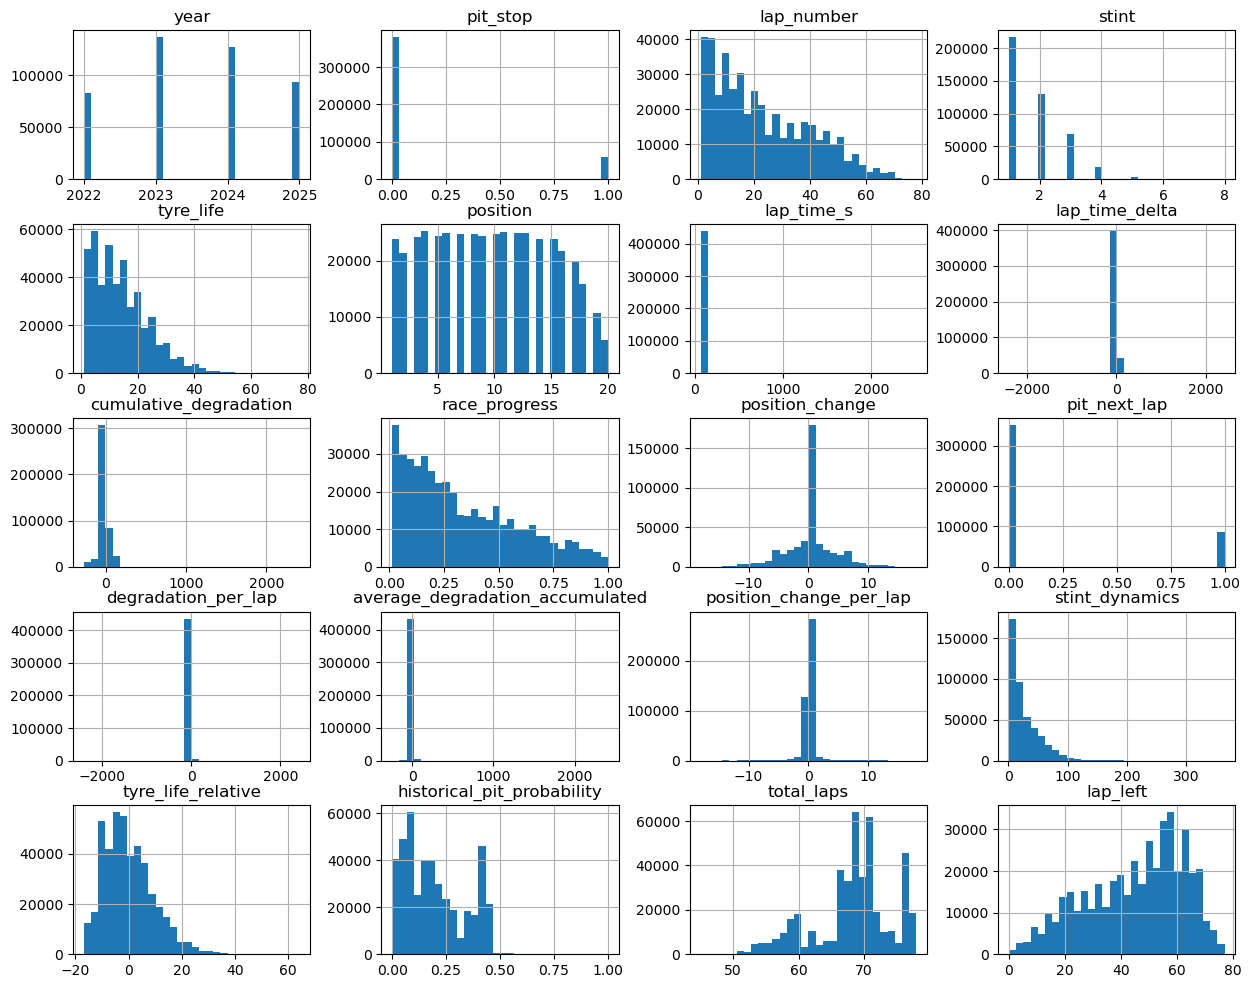

In [41]:
num_cols = df.drop([TARGET], axis=1).select_dtypes(include=np.number).columns

df.hist(figsize=(15, 12), bins=30)
plt.show()

In [42]:
right_skew_cols = [
    "tyre_life",
    "cumulative_degradation",
    "stint_dynamics",
    "lap_time_s",
    "degradation_per_lap",
    "average_degradation_accumulated"
]

### Encode cat cols

In [46]:
# Normalize -> Scale -> Encode
from sklearn.preprocessing import PowerTransformer

# Step 1: only skew correction
power_transform = ColumnTransformer([
    ('power',
     PowerTransformer(
         method='yeo-johnson',
         standardize=False
     ),
     right_skew_cols)
],
remainder='passthrough',
verbose_feature_names_out=False)
power_transform.set_output(transform='pandas')

# Step 2: scale ALL numerical cols
scaling_encoding = ColumnTransformer([
    ('scale', StandardScaler(), num_cols),

    ('onehot',
     OneHotEncoder(drop='first', sparse_output=False),
     ['compound', 'race'])
],
remainder='passthrough',
verbose_feature_names_out=False)
scaling_encoding.set_output(transform='pandas')

lr_pipeline = Pipeline([
    ('power', power_transform),

    ('preprocess', scaling_encoding),

    ('model', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(lr_pipeline, df.drop([TARGET, 'driver'], axis=1), df[TARGET], cv=5, scoring='roc_auc')
print(f'Logistic Regression Cross-validated AUC scores: {scores}')
print(f'Mean AUC: {scores.mean():.4f}, Std AUC: {scores.std():.4f}')

Logistic Regression Cross-validated AUC scores: [0.88288408 0.88471177 0.88362054 0.88431136 0.88400147]
Mean AUC: 0.8839, Std AUC: 0.0006


### Need more feature extraction since Linear model cannot capture combined features